# 01 — Exploratory Data Analysis

**Goal:** Understand the feature matrix before any modelling.
Three questions drive every section:
1. Are per-species distributions what biology predicts?
2. Is the published RESTRICT/FACILITATE pattern (RM ↔ ARG) visible in the new species?
3. Which features vary between species (Q1 signal) vs within species (Q2 signal)?

**Sections:**
1. Per-species summary statistics — confirm the numbers make sense
2. Defence system prevalence — which systems exist in which species?
3. RESTRICT/FACILITATE check — Spearman correlations per species vs published findings
4. Variance decomposition — between-species vs within-species feature variance

## Imports and data load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats

ROOT    = Path("..")
PROC    = ROOT / "data" / "processed"
FIG_DIR = ROOT / "results" / "figures" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Load feature matrix ───────────────────────────────────────────────────
fm = pd.read_parquet(PROC / "feature_matrix.parquet")

# ── Column groups ──────────────────────────────────────────────────────────
dp_cols    = [c for c in fm.columns if c.startswith("dp_")]   # defence P/A (274)
dc_cols    = [c for c in fm.columns if c.startswith("dc_")]   # defence counts (274)
ad_cols    = [c for c in fm.columns if c.startswith("ad_")]   # anti-defence P/A (29)
label_cols = ["species", "arg_burden_tertile", "country",
              "year_bin", "complex_member", "sequence_type", "mlst_scheme"]

# Shorthand: features only (no label cols)
feat_cols  = [c for c in fm.columns if c not in label_cols]

SPECIES_ORDER = ["kpneumoniae", "ecloaceae", "abaumannii",
                 "efaecium", "paeruginosa", "saureus"]

SPECIES_LABELS = {
    "kpneumoniae": "K. pneumoniae",
    "ecloaceae":   "E. cloacae complex",
    "abaumannii":  "A. baumannii",
    "efaecium":    "E. faecium",
    "paeruginosa": "P. aeruginosa",
    "saureus":     "S. aureus",
}

print(f"Feature matrix loaded: {fm.shape[0]} genomes × {fm.shape[1]} columns")
print(f"  Feature columns:  {len(feat_cols)}")
print(f"  Label columns:    {len(label_cols)}")
print(f"  Species: {fm['species'].value_counts().to_dict()}")

Feature matrix loaded: 878 genomes × 631 columns
  Feature columns:  624
  Label columns:    7
  Species: {'saureus': 150, 'paeruginosa': 150, 'abaumannii': 150, 'efaecium': 150, 'ecloaceae': 146, 'kpneumoniae': 132}


## Section 1 — Per-species summary statistics

### What we are looking for and why

Before plotting anything, read the numbers. A table of medians and IQRs tells you:
- Whether each species has the ARG and defence burden you expect from the literature
- Whether any species has near-zero variance on a key feature (which would make it
  uninformative for that species' modelling)
- Whether the published *Acinetobacter* finding is consistent with the new species
  at a glance — A. baumannii should have the *fewest* defence systems and relatively
  *high* ARG burden, because IC2 clones have depauperate defence repertoires that
  allow MGE entry

**Key variables to summarise:**
- `defence_system_count` — how many distinct defence types per genome
- `arg_count_unique` — how many distinct ARGs per genome (Q2 target)
- `ime_count_unique` — how many distinct ICE/IME elements
- `is_count_total` — total IS elements (abundant MGE proxies)
- `adef_system_count` — anti-defence system count (proxy for anti-defence burden)

**What we do NOT do here:** We do not test significance yet. Descriptive statistics
first; inference in Phase 6+. This is the same discipline as checking your gel
before running the Western blot analysis.

In [2]:
# ── Core count variables to summarise ────────────────────────────────────────
SUMMARY_VARS = [
    "defence_system_count",
    "arg_count_unique",
    "ime_count_unique",
    "is_count_total",
    "adef_system_count",
    "hmrg_metal_total",
]

# ── Per-species summary table: median [IQR], min–max ─────────────────────────
rows = []
for sp in SPECIES_ORDER:
    sub = fm[fm["species"] == sp]
    row = {"species": SPECIES_LABELS[sp], "n": len(sub)}
    for v in SUMMARY_VARS:
        q1  = sub[v].quantile(0.25)
        med = sub[v].median()
        q3  = sub[v].quantile(0.75)
        mn  = sub[v].min()
        mx  = sub[v].max()
        row[v] = f"{med:.0f} [{q1:.0f}–{q3:.0f}]  ({mn:.0f}–{mx:.0f})"
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("species")

print("Per-species summary: median [IQR]  (min–max)")
print("=" * 90)
print(summary_df.to_string())
print()
print("Column key:")
print("  defence_system_count : distinct defence types in genome")
print("  arg_count_unique     : distinct ARG genes (ResFinder)")
print("  ime_count_unique     : distinct ICE/IME elements (ICEberg)")
print("  is_count_total       : total IS elements (ISEScan)")
print("  adef_system_count    : anti-defence system count (DF anti-defence)")
print("  hmrg_metal_total     : metal resistance genes (AMRFinderPlus)")

Per-species summary: median [IQR]  (min–max)
                      n defence_system_count   arg_count_unique    ime_count_unique          is_count_total adef_system_count   hmrg_metal_total
species                                                                                                                                         
K. pneumoniae       132  22 [19–27]  (10–36)  15 [8–20]  (4–34)  17 [12–19]  (1–21)     60 [42–76]  (0–132)   5 [3–6]  (1–10)  20 [7–23]  (2–54)
E. cloacae complex  146   16 [13–19]  (7–30)   6 [2–14]  (0–26)   15 [1–18]  (0–46)     42 [16–61]  (0–261)    2 [1–3]  (0–7)  19 [4–30]  (1–65)
A. baumannii        150     6 [3–10]  (1–20)  10 [6–12]  (2–19)   11 [9–13]  (0–17)     40 [22–51]  (0–156)    3 [1–3]  (0–4)     1 [1–1]  (0–8)
E. faecium          150     8 [6–10]  (2–16)   8 [6–10]  (1–16)  12 [11–14]  (1–16)  154 [116–183]  (0–237)    2 [2–2]  (0–2)     1 [1–1]  (0–8)
P. aeruginosa       150   14 [10–20]  (5–33)   6 [5–11]  (5–29)    2 [1–16]  (1–23)  

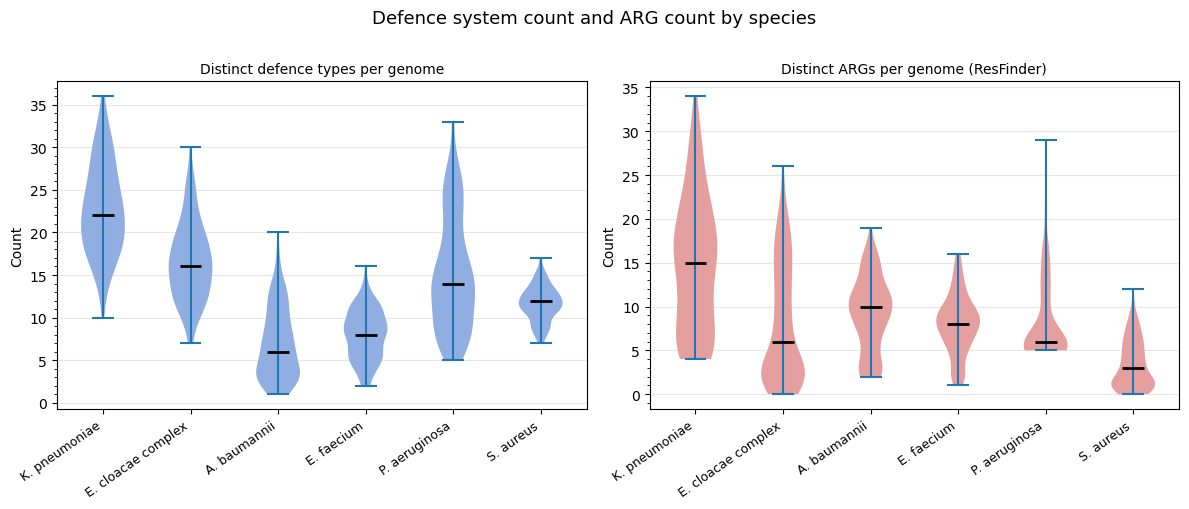

Saved: results/figures/eda/01_defence_arg_violin.png


In [3]:
# ── Violin plots: defence_system_count and arg_count_unique side by side ──────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Defence system count and ARG count by species", fontsize=13, y=1.01)

sp_labels = [SPECIES_LABELS[s] for s in SPECIES_ORDER]

for ax, var, title, colour in zip(
    axes,
    ["defence_system_count", "arg_count_unique"],
    ["Distinct defence types per genome", "Distinct ARGs per genome (ResFinder)"],
    ["#4878CF", "#D65F5F"],
):
    data_by_sp = [fm[fm["species"] == sp][var].values for sp in SPECIES_ORDER]
    parts = ax.violinplot(data_by_sp, positions=range(len(SPECIES_ORDER)),
                          showmedians=True, showextrema=True)
    for pc in parts["bodies"]:
        pc.set_facecolor(colour)
        pc.set_alpha(0.6)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2)

    ax.set_xticks(range(len(SPECIES_ORDER)))
    ax.set_xticklabels(sp_labels, rotation=35, ha="right", fontsize=9)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_defence_arg_violin.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/eda/01_defence_arg_violin.png")

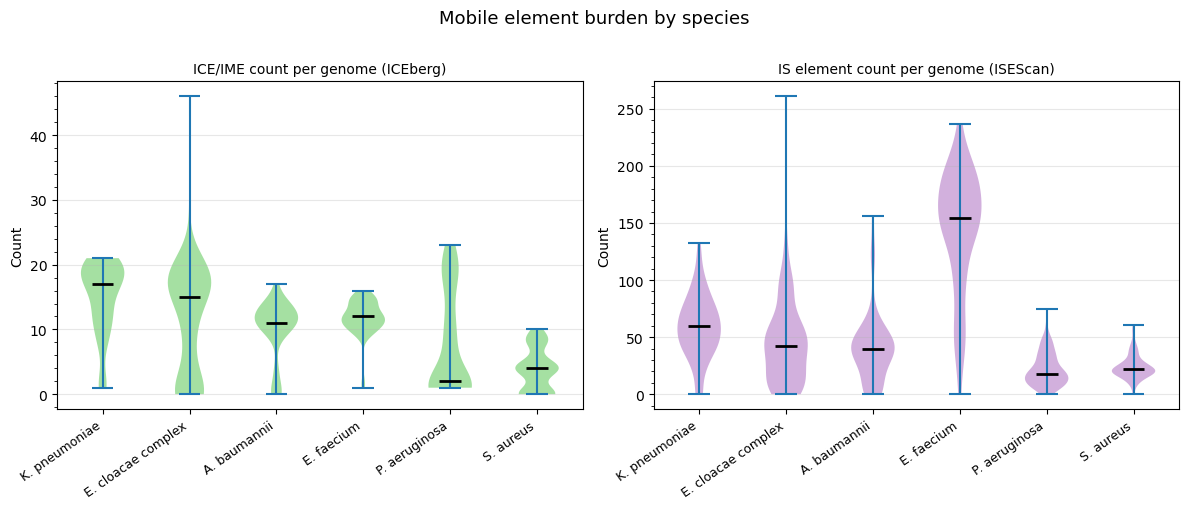

Saved: results/figures/eda/02_ime_is_violin.png


In [4]:
# ── IME and IS counts — the MGE burden landscape ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Mobile element burden by species", fontsize=13, y=1.01)

for ax, var, title, colour in zip(
    axes,
    ["ime_count_unique", "is_count_total"],
    ["ICE/IME count per genome (ICEberg)", "IS element count per genome (ISEScan)"],
    ["#6ACC65", "#B47CC7"],
):
    data_by_sp = [fm[fm["species"] == sp][var].values for sp in SPECIES_ORDER]
    parts = ax.violinplot(data_by_sp, positions=range(len(SPECIES_ORDER)),
                          showmedians=True, showextrema=True)
    for pc in parts["bodies"]:
        pc.set_facecolor(colour)
        pc.set_alpha(0.6)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2)

    ax.set_xticks(range(len(SPECIES_ORDER)))
    ax.set_xticklabels(sp_labels, rotation=35, ha="right", fontsize=9)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "02_ime_is_violin.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/eda/02_ime_is_violin.png")

### What to read from these plots

Each violin shows the *distribution shape*, not just the mean. The thick horizontal
line inside each violin is the **median**. Wide bellies = many genomes at that count;
narrow extensions = a few outliers.

**Checklist before moving to Section 2:**
- Does A. baumannii have the lowest `defence_system_count`? (Expected from the paper)
- Does K. pneumoniae have the highest ARG burden? (Consistent with its clinical
  reputation as a high-MDR species)
- Does P. aeruginosa have the lowest IME count despite having a reasonably high
  defence count? (Suggests active defence restriction of IMEs in PA)
- Does E. faecium have anomalously high IS element counts?
  (If yes: gram-positive IS-driven MGE acquisition pathway)

Surprises from this plot become hypotheses to test in Section 3.

### Section 1 comprehension check

Answer before Section 2.

**Q1.** The median defence_system_count for A. baumannii is 6 — the lowest across all
six ESKAPE species. The median for K. pneumoniae is 22. Does this mean KP genomes are
*better protected* against phage than AB genomes? What other interpretation is consistent
with this observation?

**Q2.** E. faecium has median IS count = 154, roughly four times KP's median of 60.
But EF has lower IME count (median 12) than KP (median 17). What does the difference
between IS count and IME count tell you about the *type* of MGE activity in EF vs KP?

**Q3.** You see that defence_system_count and arg_count_unique are both highest in
K. pneumoniae. If you ran a Spearman correlation on the pooled 878-genome dataset
(all species together), would you expect a positive or negative correlation between
these two variables — and why might that pooled correlation be misleading?